# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [62]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [63]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [64]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [65]:
type(registros)

list

In [66]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [67]:
dados = pd.DataFrame(registros)

print("Primeiros registros:")
dados.head()

Primeiros registros:


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [68]:
print("Quantidade de linhas e colunas:")
print(dados.shape)

Quantidade de linhas e colunas:
(336, 11)


In [69]:
print("\nNomes dos atributos:")
print(dados.columns.tolist())


Nomes dos atributos:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']


In [70]:
print("\nInformações do DataFrame:")
dados.info()


Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [71]:
print("\nEstatísticas descritivas:")
dados.describe(include="all")


Estatísticas descritivas:


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336,336,336,336,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
unique,1,7,7,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-07T19:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,336,48,48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,NaN,NaN,NaN,NaN,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,NaN,NaN,NaN,NaN,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,NaN,NaN,NaN,NaN,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,NaN,NaN,NaN,NaN,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,NaN,NaN,NaN,NaN,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0


### Principais atributos

* **Área de carga:** `cod_areacarga`
* **Data de referência:** `dat_referencia`
* **Data e horário da medição:** `din_referenciautc`
* **Valor da carga:** `val_cargaglobal`

O DataFrame possui 336 registros e 11 atributos. A variável `val_cargaglobal` representa a carga global e está armazenada em formato numérico (`float64`).


## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [76]:
dados_renomeados = dados.rename(columns={
    "cod_areacarga": "area",
    "dat_referencia": "data",
    "din_referenciautc": "data_hora",
    "val_cargaglobal": "carga",
    "val_cargaglobalcons": "carga_consistente",
    "val_cargaglobalsmmgd": "carga_smmgd",
    "val_cargasupervisionada": "carga_supervisionada",
    "val_carganaosupervisionada": "carga_nao_supervisionada",
    "val_cargammgd": "carga_mmgd",
    "val_consistencia": "consistencia"
})

dados_renomeados = dados_renomeados.drop(columns=['din_atualizacao'])
print("DataFrame organizado:")
dados_renomeados.head()

DataFrame organizado:


,area,data,data_hora,carga,carga_consistente,carga_smmgd,carga_supervisionada,carga_nao_supervisionada,carga_mmgd,consistencia
0,SP,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [77]:
print("\nValores ausentes:")
print(dados_renomeados.isnull().sum())


Valores ausentes:
area                        0
data                        0
data_hora                   0
carga                       0
carga_consistente           0
carga_smmgd                 0
carga_supervisionada        0
carga_nao_supervisionada    0
carga_mmgd                  0
consistencia                0
dtype: int64


In [78]:
print("\nTipo da variável carga:")
print(dados_renomeados["carga"].dtype)


Tipo da variável carga:
float64


In [79]:
print("\nTipo da variável data/hora:")
print(dados_renomeados["data_hora"].dtype)


Tipo da variável data/hora:
object


In [82]:
dados_renomeados["data_hora"] = pd.to_datetime(
    dados_renomeados["data_hora"]
)

dados_renomeados["data"] = pd.to_datetime(
    dados_renomeados["data"]
)

print("Novo tipo da data/hora:")
print(dados_renomeados["data_hora"].dtype)

Novo tipo da data/hora:
datetime64[ns, UTC]


In [83]:
dados_renomeados.head()

,area,data,data_hora,carga,carga_consistente,carga_smmgd,carga_supervisionada,carga_nao_supervisionada,carga_mmgd,consistencia
0,SP,2025-08-01,2025-08-01 03:30:00+00:00,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2025-08-01,2025-08-01 04:00:00+00:00,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2025-08-01,2025-08-01 04:30:00+00:00,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2025-08-01,2025-08-01 05:00:00+00:00,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2025-08-01,2025-08-01 05:30:00+00:00,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


### Decisões de tratamento

Os principais atributos foram renomeados para facilitar a leitura e a análise. Foi criado o DataFrame `dados_organizados` e foi retirado o atributo `din_atualizacao`

A variável de carga já estava em formato numérico (`float64`). A coluna de data/hora estava inicialmente como texto (`object`) e foi convertida para o formato de data/hora utilizando `pd.to_datetime()`.

A verificação de valores ausentes foi realizada com `isnull().sum()`.



## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [84]:
carga_minima = dados_renomeados["carga"].min()
carga_maxima = dados_renomeados["carga"].max()
carga_media = dados_renomeados["carga"].mean()
carga_mediana = dados_renomeados["carga"].median()
carga_amplitude = carga_maxima - carga_minima
quantidade_medicoes = len(dados_renomeados)

print(f"Carga mínima: {carga_minima:.2f}")
print(f"Carga máxima: {carga_maxima:.2f}")
print(f"Carga média: {carga_media:.2f}")
print(f"Mediana: {carga_mediana:.2f}")
print(f"Amplitude: {carga_amplitude:.2f}")
print(f"Quantidade total de medições: {quantidade_medicoes}")

Carga mínima: 12139.25
Carga máxima: 23185.31
Carga média: 17870.83
Mediana: 18199.13
Amplitude: 11046.06
Quantidade total de medições: 336


### Interpretação

A carga máxima foi de aproximadamente 23.185,31, a carga média foi de aproximadamente 17.870,83. A mediana foi de aproximadamente 18.199,13.

A diferença entre a média e a mediana é pequena, indicando que o comportamento central dos dados é semelhante. O valor máximo está acima da média isolado, mas não é suficiente, para caracterizar todo o comportamento do período.

A amplitude entre a carga máxima e a mínima é de aproximadamente 11.046,06, uma variação significativa da carga ao longo do período.


## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [86]:
limiar_alta_demanda = carga_maxima * 0.90

alta_demanda = dados_renomeados[
    dados_renomeados["carga"] > limiar_alta_demanda
].copy()

quantidade_alta_demanda = len(alta_demanda)

percentual_alta_demanda = (
    quantidade_alta_demanda / quantidade_medicoes
) * 100

print(f"Limiar de alta demanda: {limiar_alta_demanda:.2f}")
print(f"Quantidade de registros de alta demanda: {quantidade_alta_demanda}")
print(f"Percentual de alta demanda: {percentual_alta_demanda:.2f}%")


Limiar de alta demanda: 20866.78
Quantidade de registros de alta demanda: 50
Percentual de alta demanda: 14.88%


In [94]:
carga_max = dados_renomeados["carga"].idxmax()

print(f"Registro correspondente ao pico:{carga_max}")

Registro correspondente ao pico:37


In [95]:
print("Momento do pico:")
print(dados_renomeados.loc[carga_max, "data_hora"])

Momento do pico:
2025-08-01 22:00:00+00:00


### Interpretação

Foi considerado como período de alta demanda todo registro que a carga fosse superior a 90% da carga máxima observada.

Esse critério permite identificar os momentos em que a carga esteve próxima do maior valor registrado.

O maior valor de carga foi identificado utilizando `idxmax()`, permitindo também localizar a data e o horário correspondente ao pico.


## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [100]:
acima_media = dados_renomeados[
    dados_renomeados["carga"] > carga_media
].copy()

quantidade_acima_media = len(acima_media)

percentual_acima_media = (
    quantidade_acima_media / quantidade_medicoes) * 100

print("Critério escolhido: carga acima da média")
print(f"Quantidade de registros: {quantidade_acima_media}")
print(f"Percentual: {percentual_acima_media:.2f}%")

Critério escolhido: carga acima da média
Quantidade de registros: 184
Percentual: 54.76%


In [101]:
print("\nRegistros acima da média:")
acima_media.head()


Registros acima da média:


,area,data,data_hora,carga,carga_consistente,carga_smmgd,carga_supervisionada,carga_nao_supervisionada,carga_mmgd,consistencia
15,SP,2025-08-01,2025-08-01 11:00:00+00:00,18096.023,18096.023,17415.600,15954.084,1461.5154,680.4232,0
16,SP,2025-08-01,2025-08-01 11:30:00+00:00,18629.395,18629.395,17409.600,15953.951,1455.6488,1219.7958,0
17,SP,2025-08-01,2025-08-01 12:00:00+00:00,18825.176,18825.176,17097.592,15648.688,1448.9040,1727.5842,0
18,SP,2025-08-01,2025-08-01 12:30:00+00:00,19056.504,19056.504,16850.477,15407.757,1442.7206,2206.0276,0
19,SP,2025-08-01,2025-08-01 13:00:00+00:00,19427.822,19427.822,16792.590,15353.431,1439.1598,2635.2324,0


In [103]:
print("COMPARAÇÃO DOS CRITÉRIOS")
print()

print(f"Alta demanda (> 90% do máximo):")
print(f"Quantidade: {quantidade_alta_demanda}")
print(f"Percentual: {percentual_alta_demanda:.2f}%")

print()

print(f"Acima da média:")
print(f"Quantidade: {quantidade_acima_media}")
print(f"Percentual: {percentual_acima_media:.2f}%")

COMPARAÇÃO DOS CRITÉRIOS

Alta demanda (> 90% do máximo):
Quantidade: 50
Percentual: 14.88%

Acima da média:
Quantidade: 184
Percentual: 54.76%


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

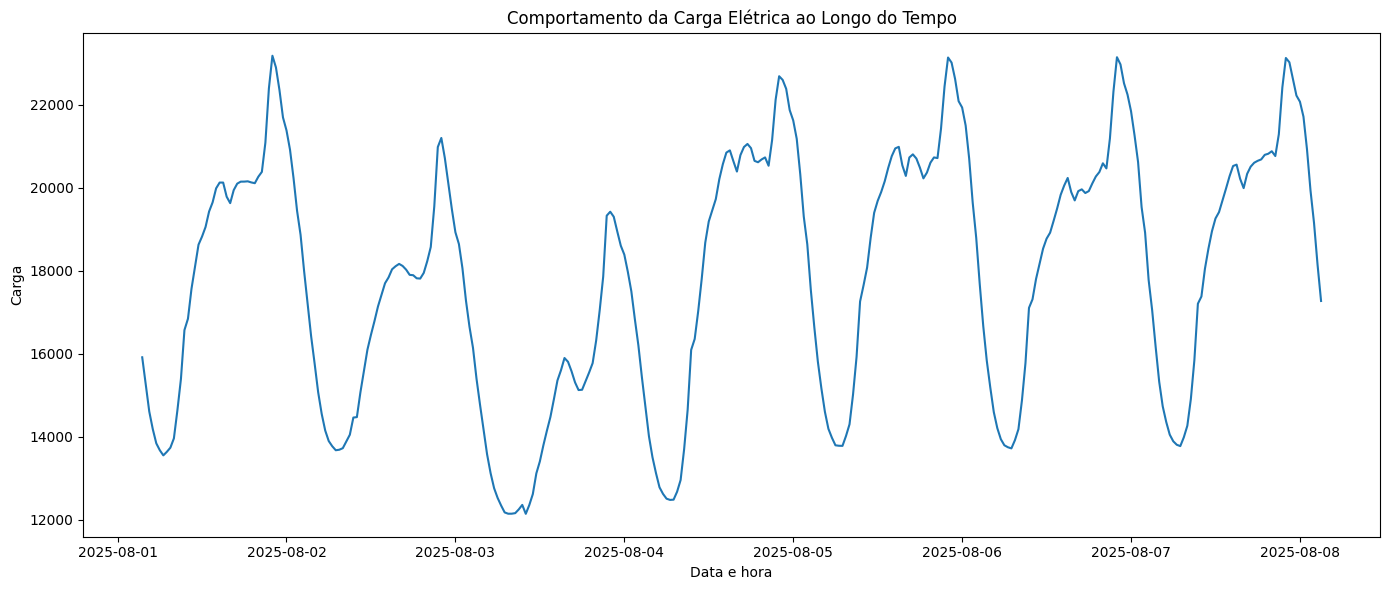

In [109]:
plt.figure(figsize=(14, 6))

plt.plot(
    dados_renomeados["data_hora"],
    dados_renomeados["carga"]
)

plt.title("Comportamento da Carga Elétrica ao Longo do Tempo")
plt.xlabel("Data e hora")
plt.ylabel("Carga")

plt.tight_layout()
plt.show()

### Gráfico 1

O gráfico mostra a variação da carga elétrica ao longo do período analisado. É possível observar os momentos de aumento e redução da demanda e identificar visualmente os períodos próximos ao maior valor registrado.


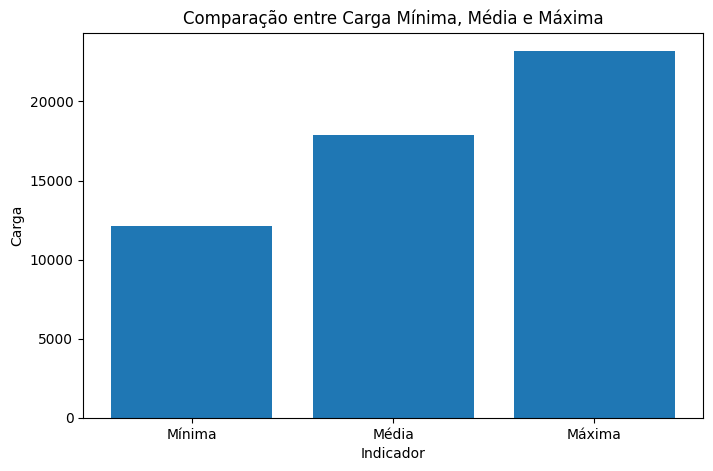

In [110]:
# Gráfico 2 — Comparação dos indicadores

plt.figure(figsize=(8, 5))

plt.bar(
    ["Mínima", "Média", "Máxima"],
    [carga_minima, carga_media, carga_maxima]
)

plt.title("Comparação entre Carga Mínima, Média e Máxima")
plt.xlabel("Indicador")
plt.ylabel("Carga")

plt.show()

### Interpretação do Gráfico 2

O gráfico permite comparar diretamente os valores mínimo, médio e máximo da carga elétrica. Observa-se que a carga máxima está consideravelmente acima da mínima, enquanto a média apresenta um valor intermediário, representando o comportamento central do período.


## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [113]:
# DESAFIO 7 — Síntese para o relatório

momento_pico = dados_renomeados.loc[
    carga_max, "data_hora"
]

resumo_resultados = f"""
Região analisada: SP — São Paulo
Período analisado: 01/08/2025 a 07/08/2025

Quantidade de registros: {quantidade_medicoes}

Carga mínima: {carga_minima:.2f}
Carga máxima: {carga_maxima:.2f}
Carga média: {carga_media:.2f}
Mediana: {carga_mediana:.2f}
Amplitude: {carga_amplitude:.2f}

Limiar de alta demanda (90% da máxima): {limiar_alta_demanda:.2f}
Registros de alta demanda: {quantidade_alta_demanda}
Percentual de alta demanda: {percentual_alta_demanda:.2f}%

Momento do pico: {momento_pico}

Segundo critério: carga acima da média
Registros acima da média: {quantidade_acima_media}
Percentual acima da média: {percentual_acima_media:.2f}%
"""

print(resumo_resultados)


Região analisada: SP — São Paulo
Período analisado: 01/08/2025 a 07/08/2025

Quantidade de registros: 336

Carga mínima: 12139.25
Carga máxima: 23185.31
Carga média: 17870.83
Mediana: 18199.13
Amplitude: 11046.06

Limiar de alta demanda (90% da máxima): 20866.78
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%

Momento do pico: 2025-08-01 22:00:00+00:00

Segundo critério: carga acima da média
Registros acima da média: 184
Percentual acima da média: 54.76%



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [111]:
!pip -q install -U google-genai

In [112]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [114]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [115]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

# Relatório Técnico de Análise de Carga Elétrica

**Setor:** Análise de Dados / Setor Elétrico  
**Região Analisada:** SP — São Paulo  
**Período:** 01/08/2025 a 07/08/2025  

---

### 1. Caracterização do Conjunto Analisado
O conjunto de dados compreende o monitoramento do consumo/carga elétrica na região de São Paulo (SP) durante o período de 01/08/2025 a 07/08/2025. No total, foram avaliados **336 registros** contínuos durante a semana analisada.

---

### 2. Principais Indicadores
Com base na totalidade das medições do período, observam-se os seguintes parâmetros estatísticos da carga:

* **Carga Mínima:** 12.139,25
* **Carga Máxima:** 23.185,31
* **Carga Média:** 17.870,83
* **Mediana:** 18.199,13
* **Amplitude Total:** 11.046,06

---

### 3. Análise dos Períodos de Alta Demanda
O limiar de alta demanda foi estabelecido em **20.866,78**, equivalente a 90% do valor máximo registrado no período.

* **Registros em Alta Demanda:** 50
* **Percentual em Alta Demanda:** 14,88% do tempo t

In [116]:
dados_renomeados["carga"] > limiar_alta_demanda

,carga
0,False
1,False
2,False
3,False
4,False
...,...
331,True
332,False
333,False
334,False


## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

_Escreva aqui a versão final revisada._

1. Os indicadores foram utilizados corretamente?

Sim. Os valores apresentados no relatório foram comparados com os resultados calculados no notebook. A carga mínima, máxima, média, mediana e amplitude estão de acordo com os indicadores calculados diretamente a partir dos dados.

2. Há alguma afirmação que não pode ser confirmada pelos dados?

O relatório foi cuidadoso ao afirmar que não é possível determinar as causas das variações da carga utilizando somente os dados analisados.

3. Houve interpretação exagerada ou causalidade não demonstrada?

Não foram identificadas explicações causais apresentadas como fatos. O relatório ressalta que a análise está limitada ao comportamento quantitativo da carga.

4. Que alterações a equipe realizou no texto?

Eu conferi os valores apresentados pelo relatório com os cálculos realizados no notebook e ajustei a descrição do critério de alta demanda para indicar que foram considerados registros com carga superior a 90% da carga máxima.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**